#**Tahap Pelatihan & Evaluasi Model Multiclass**

## **Langkah 9: Model Training Multiclass**

####**9.1 Setup dan Verifikasi**

In [ ]:
os.makedirs(FRAMEWORK_MODELS_DIR_IIOT, exist_ok=True)
os.makedirs(CONFUSION_MATRIX_DIR_IIOT, exist_ok=True)
os.makedirs(VISUALIZATION_DIR_IIOT,    exist_ok=True)

label_list  = [LABEL_NAMES_IIOT[i] for i in range(N_CLASSES)]
label_index = list(range(N_CLASSES))

print(f"X_train_final : {X_train_final.shape}")
print(f"y_train_final : {y_train_final.shape}")
print(f"X_test        : {X_test.shape}")
print(f"y_test        : {y_test.shape}")
print(f"N_CLASSES     : {N_CLASSES}")

print(f"\nDistribusi y_train_final:")
for enc in range(N_CLASSES):
    n = int((y_train_final == enc).sum())
    print(f"  {enc} {LABEL_NAMES_IIOT[enc]:<18} : {n:>10,}")

print(f"\nDistribusi y_test:")
for enc in range(N_CLASSES):
    n = int((y_test == enc).sum())
    print(f"  {enc} {LABEL_NAMES_IIOT[enc]:<18} : {n:>10,}")

mem = psutil.virtual_memory()
print(f"\nRAM tersisa sebelum training: {mem.available / 1024**3:.2f} GB")

X_train_final : (1221113, 71)
y_train_final : (1221113,)
X_test        : (45319, 71)
y_test        : (45319,)
N_CLASSES     : 8

Distribusi y_train_final:
  0 Benign             :    163,578
  1 Brute_Force        :    163,578
  2 DDoS               :    163,578
  3 DoS                :    163,578
  4 MITM/Spoofing      :    163,578
  5 Malware/Mirai      :    163,578
  6 Recon              :     76,067
  7 Web_Based          :    163,578

Distribusi y_test:
  0 Benign             :     15,734
  1 Brute_Force        :        571
  2 DDoS               :      6,097
  3 DoS                :      6,362
  4 MITM/Spoofing      :      2,750
  5 Malware/Mirai      :      2,773
  6 Recon              :     10,096
  7 Web_Based          :        936

RAM tersisa sebelum training: 47.19 GB


####**9.2 Setup Helper Functions**

In [ ]:
def evaluate_multiclass(model_name, y_true, y_pred, y_prob=None):
    acc          = accuracy_score(y_true, y_pred)
    macro_prec   = precision_score(y_true, y_pred, average='macro',    zero_division=0)
    macro_rec    = recall_score(y_true, y_pred,    average='macro',    zero_division=0)
    macro_f1     = f1_score(y_true, y_pred,        average='macro',    zero_division=0)
    weighted_f1  = f1_score(y_true, y_pred,        average='weighted', zero_division=0)
    mcc          = matthews_corrcoef(y_true, y_pred)

    roc_auc = None
    if y_prob is not None:
        try:
            roc_auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
        except Exception:
            roc_auc = None

    per_class = classification_report(
        y_true, y_pred,
        target_names=label_list,
        output_dict=True,
        zero_division=0
    )

    return {
        'model'       : model_name,
        'accuracy'    : round(float(acc),        6),
        'macro_prec'  : round(float(macro_prec), 6),
        'macro_recall': round(float(macro_rec),  6),
        'macro_f1'    : round(float(macro_f1),   6),
        'weighted_f1' : round(float(weighted_f1),6),
        'mcc'         : round(float(mcc),        6),
        'roc_auc_ovr' : round(float(roc_auc), 6) if roc_auc is not None else None,
        'per_class'   : per_class,
    }

def print_results(model_name, results):
    print(f"\n{model_name} - Hasil Evaluasi:")
    print(f"  Accuracy        : {results['accuracy']:.6f}")
    print(f"  Macro Precision : {results['macro_prec']:.6f}")
    print(f"  Macro Recall    : {results['macro_recall']:.6f}")
    print(f"  Macro F1-Score  : {results['macro_f1']:.6f}")
    print(f"  MCC             : {results['mcc']:.6f}")

    print(f"\n  Per-class metrics:")
    print(f"  {'Kelas':<20} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
    print(f"  {'-'*57}")
    for name in label_list:
        pc      = results['per_class'][name]
        support = int(pc['support'])
        print(f"  {name:<20} {pc['precision']:>10.4f} {pc['recall']:>10.4f} "
              f"{pc['f1-score']:>10.4f} {support:>10,}")

def save_confusion_matrix(y_true, y_pred, model_name, save_dir):
    cm  = confusion_matrix(y_true, y_pred, labels=label_index)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=label_list, yticklabels=label_list, ax=ax
    )
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label',      fontsize=11)
    ax.set_title(f'Confusion Matrix - {model_name}\n(Multiclass, CIC IIoT 2025)',
                 fontsize=12)
    plt.xticks(rotation=30, ha='right', fontsize=9)
    plt.yticks(rotation=0,  fontsize=9)
    plt.tight_layout()
    path = os.path.join(save_dir, f'CM_{model_name}_multiclass.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"\n  Confusion matrix tersimpan: {path}")
    return cm

print("  evaluate_multiclass : OK")
print("  print_results       : OK")
print("  save_confusion_matrix : OK")

all_results    = {}
all_train_time = {}

  evaluate_multiclass : OK
  print_results       : OK
  save_confusion_matrix : OK


####**9.3 Random Forest**

Parameter RF:
  n_estimators           : 100
  max_depth              : 15
  min_samples_split      : 5
  min_samples_leaf       : 2
  max_features           : sqrt
  n_jobs                 : -1
  random_state           : 42
  verbose                : 1

Memulai training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   40.2s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.7min finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s


Training selesai dalam : 103.6 detik

Prediksi pada test set...


[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.1s finished


Prediksi selesai dalam : 0.21 detik

RandomForest - Hasil Evaluasi:
  Accuracy        : 0.991505
  Macro Precision : 0.994163
  Macro Recall    : 0.992387
  Macro F1-Score  : 0.993238
  MCC             : 0.989191

  Per-class metrics:
  Kelas                 Precision     Recall         F1    Support
  ---------------------------------------------------------
  Benign                   0.9833     0.9999     0.9915     15,734
  Brute_Force              0.9983     1.0000     0.9991        571
  DDoS                     0.9997     0.9864     0.9930      6,097
  DoS                      0.9920     0.9950     0.9935      6,362
  MITM/Spoofing            0.9853     0.9982     0.9917      2,750
  Malware/Mirai            0.9960     0.9870     0.9915      2,773
  Recon                    0.9988     0.9780     0.9883     10,096
  Web_Based                1.0000     0.9947     0.9973        936


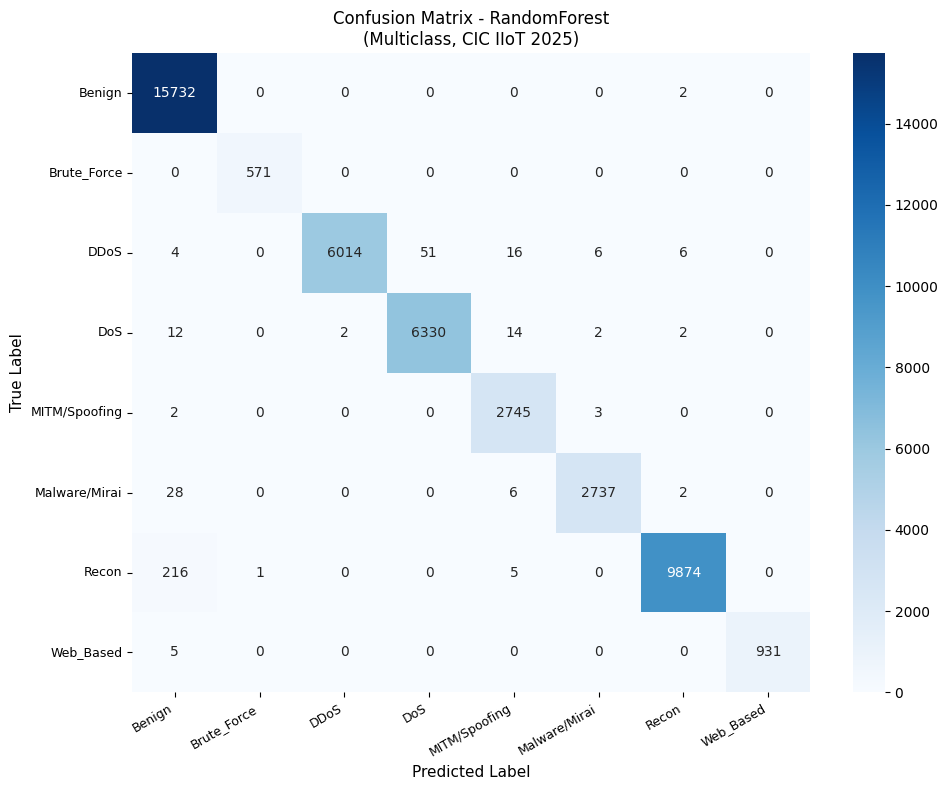


  Confusion matrix tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Results/Confusion_Matrices/CM_RandomForest_multiclass.png

Model RandomForest tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Models/RF_multiclass.pkl
RandomForest selesai.
RAM tersisa: 46.17 GB


In [ ]:
RF_PARAMS = {
    'n_estimators'     : 100,
    'max_depth'        : 15,
    'min_samples_split': 5,
    'min_samples_leaf' : 2,
    'max_features'     : 'sqrt', # Default Nila Klasifikasi
    'n_jobs'           : -1,
    'random_state'     : SEED,
    'verbose'          : 1
}

print(f"Parameter RF:")
for k, v in RF_PARAMS.items():
    print(f"  {k:<22} : {v}")

print(f"\nMemulai training Random Forest...")
t_rf      = time.time()
rf_model  = RandomForestClassifier(**RF_PARAMS)
rf_model.fit(X_train_final, y_train_final)
rf_train_time = time.time() - t_rf
print(f"Training selesai dalam : {rf_train_time:.1f} detik")

print(f"\nPrediksi pada test set...")
t0        = time.time()
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)
print(f"Prediksi selesai dalam : {time.time()-t0:.2f} detik")

results_rf = evaluate_multiclass('RandomForest', y_test, y_pred_rf, y_prob_rf)
print_results('RandomForest', results_rf)

save_confusion_matrix(y_test, y_pred_rf, 'RandomForest', CONFUSION_MATRIX_DIR_IIOT)

rf_path = os.path.join(FRAMEWORK_MODELS_DIR_IIOT, 'RF_multiclass.pkl')
joblib.dump(rf_model, rf_path)
print(f"\nModel RandomForest tersimpan: {rf_path}")
print(f"RandomForest selesai.")

all_results['RandomForest']    = results_rf
all_train_time['RandomForest'] = rf_train_time

del rf_model
gc.collect()

mem = psutil.virtual_memory()
print(f"RAM tersisa: {mem.available / 1024**3:.2f} GB")

####**9.4 XGBoost**

Parameter XGBoost:
  n_estimators           : 100
  max_depth              : 8
  learning_rate          : 0.1
  subsample              : 0.8
  colsample_bytree       : 0.8
  objective              : multi:softmax
  num_class              : 8
  eval_metric            : mlogloss
  use_label_encoder      : False
  tree_method            : hist
  device                 : cuda
  random_state           : 42
  n_jobs                 : -1

XGBoost GPU tidak tersedia, menggunakan CPU.

Memulai training XGBoost...
[0]	validation_0-mlogloss:1.77279
[50]	validation_0-mlogloss:0.04991
[99]	validation_0-mlogloss:0.02402
Training selesai dalam : 107.4 detik

Prediksi pada test set...
Prediksi selesai dalam : 0.44 detik

XGBoost - Hasil Evaluasi:
  Accuracy        : 0.994439
  Macro Precision : 0.996157
  Macro Recall    : 0.995207
  Macro F1-Score  : 0.995669
  MCC             : 0.992915

  Per-class metrics:
  Kelas                 Precision     Recall         F1    Support
  -----------------------

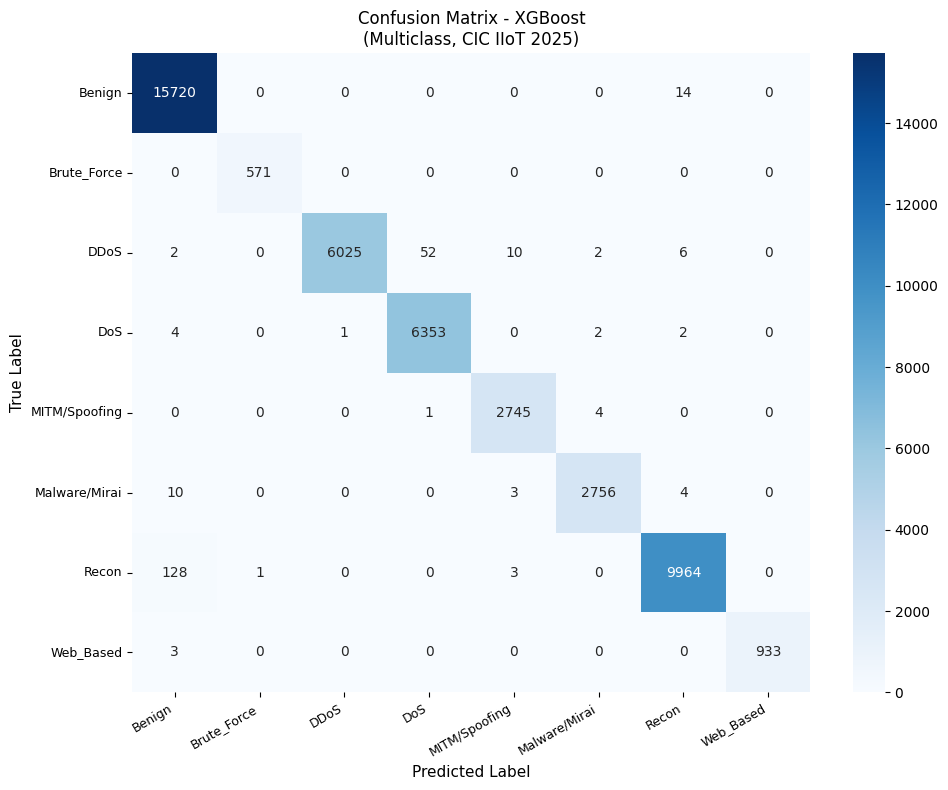


  Confusion matrix tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Results/Confusion_Matrices/CM_XGBoost_multiclass.png

Model XGBoost tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Models/XGBoost_multiclass.json
XGBoost selesai.
RAM tersisa: 46.03 GB


In [ ]:
XGB_PARAMS = {
    'n_estimators'     : 100,
    'max_depth'        : 8,
    'learning_rate'    : 0.1,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'objective'        : 'multi:softmax',
    'num_class'        : N_CLASSES,
    'eval_metric'      : 'mlogloss',
    'use_label_encoder': False,
    'tree_method'      : 'hist',
    'device'           : 'cuda',
    'random_state'     : SEED,
    'n_jobs'           : -1,
}

print(f"Parameter XGBoost:")
for k, v in XGB_PARAMS.items():
    print(f"  {k:<22} : {v}")

try:
    xgb_test = xgb.XGBClassifier(device='cuda', n_estimators=1)
    xgb_test.fit(X_train_final[:10], y_train_final[:10])
    print(f"\nXGBoost GPU (cuda) tersedia.")
except Exception:
    XGB_PARAMS['device'] = 'cpu'
    print(f"\nXGBoost GPU tidak tersedia, menggunakan CPU.")

print(f"\nMemulai training XGBoost...")
t_xgb     = time.time()
xgb_model = xgb.XGBClassifier(**XGB_PARAMS)
xgb_model.fit(
    X_train_final, y_train_final,
    eval_set=[(X_test, y_test)],
    verbose=50
)
xgb_train_time = time.time() - t_xgb
print(f"Training selesai dalam : {xgb_train_time:.1f} detik")

print(f"\nPrediksi pada test set...")
t0         = time.time()
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)
print(f"Prediksi selesai dalam : {time.time()-t0:.2f} detik")

results_xgb = evaluate_multiclass('XGBoost', y_test, y_pred_xgb, y_prob_xgb)
print_results('XGBoost', results_xgb)

save_confusion_matrix(y_test, y_pred_xgb, 'XGBoost', CONFUSION_MATRIX_DIR_IIOT)

xgb_path = os.path.join(FRAMEWORK_MODELS_DIR_IIOT, 'XGBoost_multiclass.json')
xgb_model.save_model(xgb_path)
print(f"\nModel XGBoost tersimpan: {xgb_path}")
print(f"XGBoost selesai.")

all_results['XGBoost']    = results_xgb
all_train_time['XGBoost'] = xgb_train_time

del xgb_model
gc.collect()

mem = psutil.virtual_memory()
print(f"RAM tersisa: {mem.available / 1024**3:.2f} GB")

####**9.5 LightGBM**

Parameter LightGBM:
  n_estimators           : 100
  max_depth              : 8
  learning_rate          : 0.1
  num_leaves             : 31
  subsample              : 0.8
  colsample_bytree       : 0.8
  objective              : multiclass
  num_class              : 8
  metric                 : multi_logloss
  device                 : cpu
  random_state           : 42
  n_jobs                 : -1
  verbose                : -1
  class_weight           : None

Memulai training LightGBM (CPU)...
[50]	valid_0's multi_logloss: 0.0341305
[100]	valid_0's multi_logloss: 0.0201878
Training selesai dalam : 92.6 detik

Prediksi pada test set...
Prediksi selesai dalam : 0.97 detik

LightGBM - Hasil Evaluasi:
  Accuracy        : 0.995079
  Macro Precision : 0.996792
  Macro Recall    : 0.995834
  Macro F1-Score  : 0.996306
  MCC             : 0.993728

  Per-class metrics:
  Kelas                 Precision     Recall         F1    Support
  --------------------------------------------------------

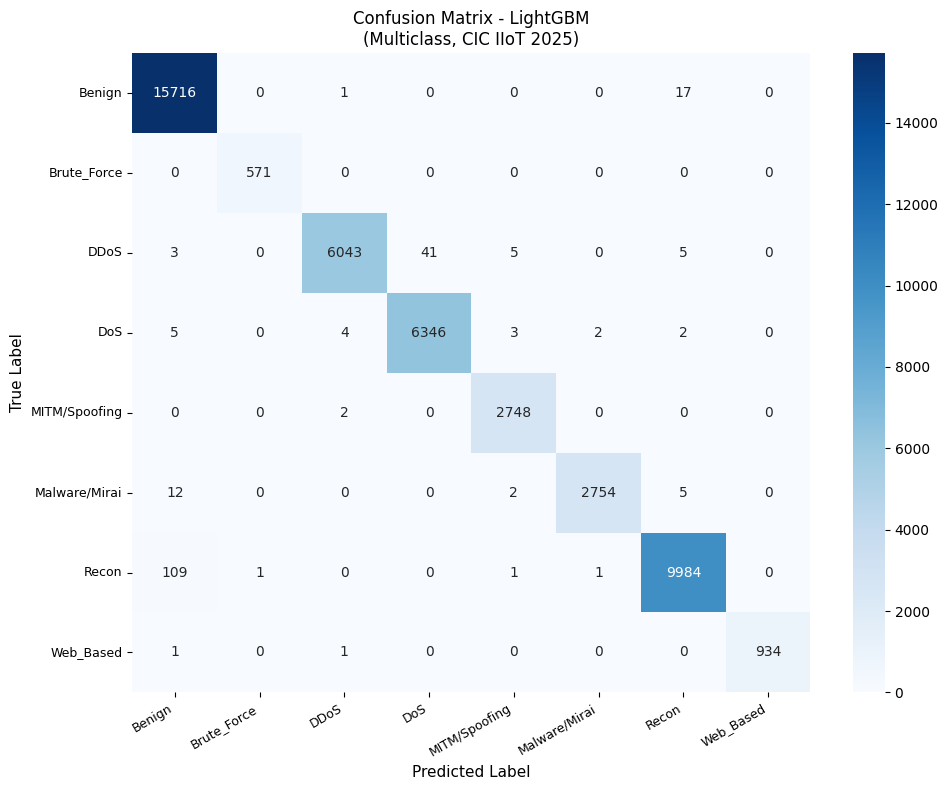


  Confusion matrix tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Results/Confusion_Matrices/CM_LightGBM_multiclass.png

Model LightGBM tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Models/LightGBM_multiclass.pkl
LightGBM selesai.
RAM tersisa: 45.66 GB


In [ ]:
LGB_PARAMS = {
    'n_estimators'     : 100,
    'max_depth'        : 8,
    'learning_rate'    : 0.1,
    'num_leaves'       : 31,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'objective'        : 'multiclass',
    'num_class'        : N_CLASSES,
    'metric'           : 'multi_logloss',
    'device'           : 'cpu', # Menggunakan CPU untuk menghindari bug best_split_info GPU
    'random_state'     : SEED,
    'n_jobs'           : -1,
    'verbose'          : -1,
    'class_weight'     : None,
}

print(f"Parameter LightGBM:")
for k, v in LGB_PARAMS.items():
    print(f"  {k:<22} : {v}")

try:
    lgb_test = lgb.LGBMClassifier(device='gpu', n_estimators=1, verbose=-1)
    lgb_test.fit(X_train_final[:10], y_train_final[:10])
    # Jika sukses tapi tetap error di atas, lebih baik kita paksakan CPU
    # print(f"\nLightGBM GPU tersedia.")
except Exception:
    pass

print(f"\nMemulai training LightGBM (CPU)...")
t_lgb     = time.time()
lgb_model = lgb.LGBMClassifier(**LGB_PARAMS)
lgb_model.fit(
    X_train_final, y_train_final,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.log_evaluation(period=50)]
)
lgb_train_time = time.time() - t_lgb
print(f"Training selesai dalam : {lgb_train_time:.1f} detik")

print(f"\nPrediksi pada test set...")
t0         = time.time()
y_pred_lgb = lgb_model.predict(X_test)
y_prob_lgb = lgb_model.predict_proba(X_test)
print(f"Prediksi selesai dalam : {time.time()-t0:.2f} detik")

results_lgb = evaluate_multiclass('LightGBM', y_test, y_pred_lgb, y_prob_lgb)
print_results('LightGBM', results_lgb)

save_confusion_matrix(y_test, y_pred_lgb, 'LightGBM', CONFUSION_MATRIX_DIR_IIOT)

lgb_path = os.path.join(FRAMEWORK_MODELS_DIR_IIOT, 'LightGBM_multiclass.pkl')
joblib.dump(lgb_model, lgb_path)
print(f"\nModel LightGBM tersimpan: {lgb_path}")
print(f"LightGBM selesai.")

all_results['LightGBM']    = results_lgb
all_train_time['LightGBM'] = lgb_train_time

del lgb_model
gc.collect()

mem = psutil.virtual_memory()
print(f"RAM tersisa: {mem.available / 1024**3:.2f} GB")

####**9.6 Deep Neural Network (DNN)**

Parameter DNN:
  hidden_layers      : [128, 64, 32, 16]
  dropout_rate       : 0.3
  activation         : relu
  batch_norm         : True
  learning_rate      : 0.001
  batch_size         : 256
  epochs             : 50
  patience           : 5
  optimizer          : Adam
  loss               : sparse_categorical_crossentropy

Membangun arsitektur DNN...


Model: "DNN_multiclass"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 71)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_1 (Activation)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_2 (Activation)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_3 (Activation)              │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_4 (BatchNormalization)       │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_4 (Activation)              │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 8)              │           136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,176 (82.72 KB)

 Trainable params: 20,696 (80.84 KB)

 Non-trainable params: 480 (1.88 KB)


Total parameter : 21,176

Memulai training DNN...
Epoch 1/50
4293/4293 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8189 - loss: 0.5848
Epoch 1: val_loss improved from None to 0.11426, saving model to /content/drive/My Drive/Framework/CICIIoT2025/Models/DNN_multiclass_best.keras

Epoch 1: finished saving model to /content/drive/My Drive/Framework/CICIIoT2025/Models/DNN_multiclass_best.keras
4293/4293 ━━━━━━━━━━━━━━━━━━━━ 25s 4ms/step - accuracy: 0.9016 - loss: 0.3389 - val_accuracy: 0.9679 - val_loss: 0.1143 - learning_rate: 0.0010
Epoch 2/50
4293/4293 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9470 - loss: 0.1894
Epoch 2: val_loss improved from 0.11426 to 0.10498, saving model to /content/drive/My Drive/Framework/CICIIoT2025/Models/DNN_multiclass_best.keras

Epoch 2: finished saving model to /content/drive/My Drive/Framework/CICIIoT2025/Models/DNN_multiclass_best.keras
4293/4293 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.9491 - loss: 0.1826 - val_accuracy: 0.9711 - val_los

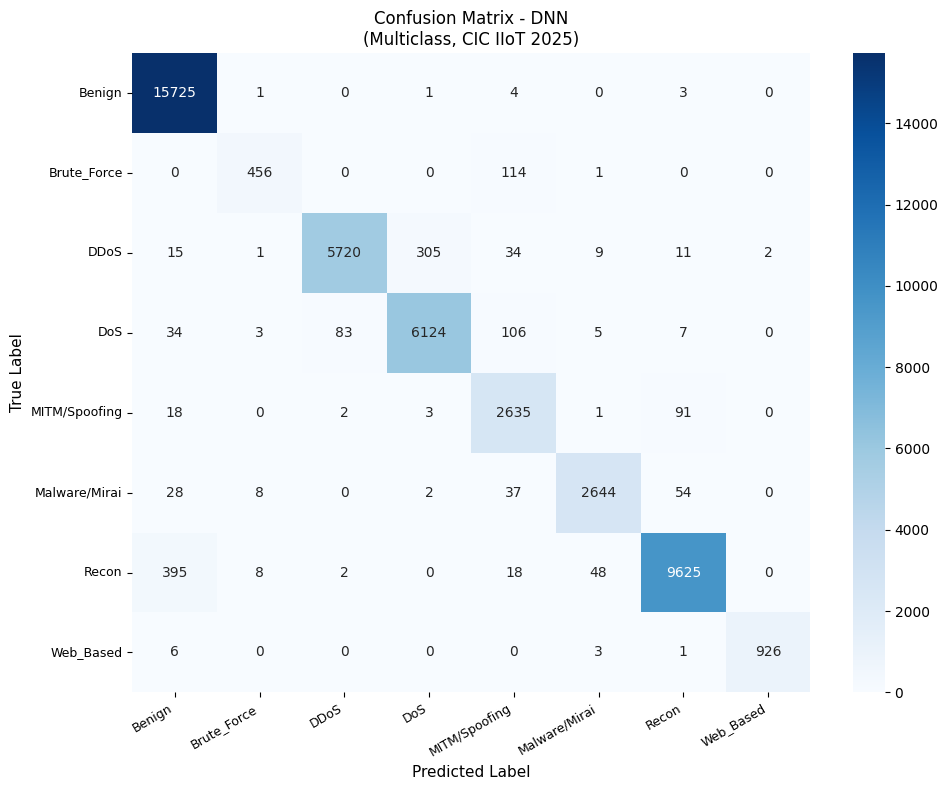


  Confusion matrix tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Results/Confusion_Matrices/CM_DNN_multiclass.png

Model DNN tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Models/DNN_multiclass.keras
DNN selesai.


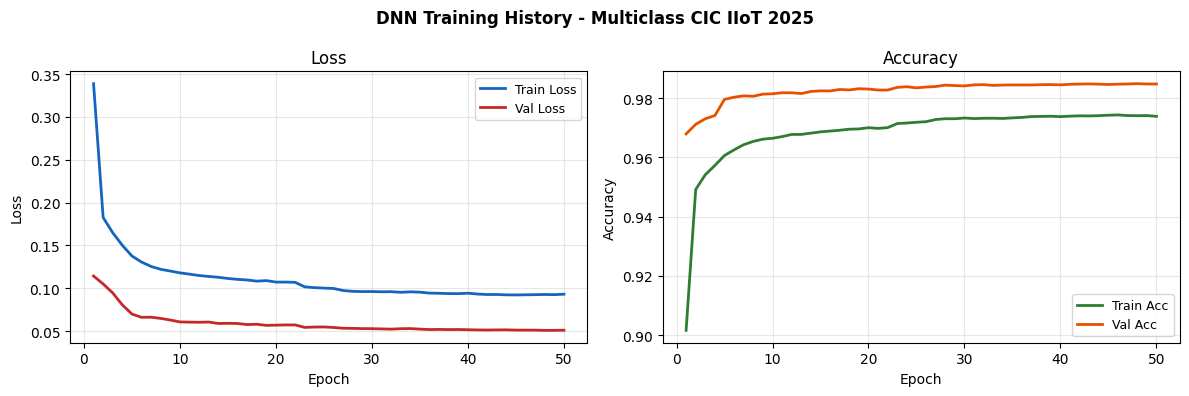

Training curve tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Results/Visualizations/Langkah9_DNN_Training_Curve.png
RAM tersisa: 45.75 GB


In [ ]:
DNN_PARAMS = {
    'hidden_layers' : [128, 64, 32, 16],
    'dropout_rate'  : 0.3,
    'activation'    : 'relu',
    'batch_norm'    : True,
    'learning_rate' : 0.001,
    'batch_size'    : 256,
    'epochs'        : 50,
    'patience'      : 5,
    'optimizer'     : 'Adam',
    'loss'          : 'sparse_categorical_crossentropy',
}

print(f"Parameter DNN:")
for k, v in DNN_PARAMS.items():
    print(f"  {k:<18} : {v}")

def build_dnn(input_dim, n_classes, hidden_layers, dropout_rate,
              activation, batch_norm, learning_rate):
    inp = keras.Input(shape=(input_dim,), name='input')
    x   = inp
    for i, units in enumerate(hidden_layers):
        x = layers.Dense(units, name=f'dense_{i+1}')(x)
        if batch_norm:
            x = layers.BatchNormalization(name=f'bn_{i+1}')(x)
        x = layers.Activation(activation, name=f'act_{i+1}')(x)
        x = layers.Dropout(dropout_rate, name=f'dropout_{i+1}')(x)
    out   = layers.Dense(n_classes, activation='softmax', name='output')(x)
    model = keras.Model(inp, out, name='DNN_multiclass')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=DNN_PARAMS['loss'],
        metrics=['accuracy']
    )
    return model

print(f"\nMembangun arsitektur DNN...")
tf.keras.backend.clear_session()
dnn_model = build_dnn(
    input_dim    = N_FEATURES,
    n_classes    = N_CLASSES,
    hidden_layers= DNN_PARAMS['hidden_layers'],
    dropout_rate = DNN_PARAMS['dropout_rate'],
    activation   = DNN_PARAMS['activation'],
    batch_norm   = DNN_PARAMS['batch_norm'],
    learning_rate= DNN_PARAMS['learning_rate'],
)
dnn_model.summary()
print(f"\nTotal parameter : {dnn_model.count_params():,}")

dnn_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=DNN_PARAMS['patience'],
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3,
        min_lr=1e-5, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(FRAMEWORK_MODELS_DIR_IIOT, 'DNN_multiclass_best.keras'),
        monitor='val_loss', save_best_only=True, verbose=1
    ),
]

print(f"\nMemulai training DNN...")
t_dnn       = time.time()
dnn_history = dnn_model.fit(
    X_train_final, y_train_final,
    epochs           = DNN_PARAMS['epochs'],
    batch_size       = DNN_PARAMS['batch_size'],
    validation_split = 0.1,
    callbacks        = dnn_callbacks,
    verbose          = 1,
    shuffle          = True,
)
dnn_train_time = time.time() - t_dnn
n_epochs_run   = len(dnn_history.history['loss'])

print(f"\nTraining selesai dalam : {dnn_train_time:.1f} detik")
print(f"Epochs dijalankan      : {n_epochs_run}/{DNN_PARAMS['epochs']}")
print(f"Final train loss       : {dnn_history.history['loss'][-1]:.4f}")
print(f"Final val loss         : {dnn_history.history['val_loss'][-1]:.4f}")
print(f"Final train acc        : {dnn_history.history['accuracy'][-1]:.4f}")
print(f"Final val acc          : {dnn_history.history['val_accuracy'][-1]:.4f}")

print(f"\nPrediksi pada test set...")
t0         = time.time()
y_prob_dnn = dnn_model.predict(X_test, batch_size=1024, verbose=0)
y_pred_dnn = np.argmax(y_prob_dnn, axis=1)
print(f"Prediksi selesai dalam : {time.time()-t0:.2f} detik")

results_dnn = evaluate_multiclass('DNN', y_test, y_pred_dnn, y_prob_dnn)
print_results('DNN', results_dnn)

save_confusion_matrix(y_test, y_pred_dnn, 'DNN', CONFUSION_MATRIX_DIR_IIOT)

dnn_final_path = os.path.join(FRAMEWORK_MODELS_DIR_IIOT, 'DNN_multiclass.keras')
dnn_model.save(dnn_final_path)

dnn_hist_path = os.path.join(FRAMEWORK_MODELS_DIR_IIOT, 'DNN_multiclass_history.json')
dnn_hist_dict = {
    'loss'        : [float(v) for v in dnn_history.history['loss']],
    'val_loss'    : [float(v) for v in dnn_history.history['val_loss']],
    'accuracy'    : [float(v) for v in dnn_history.history['accuracy']],
    'val_accuracy': [float(v) for v in dnn_history.history['val_accuracy']],
    'n_epochs'    : n_epochs_run,
}
with open(dnn_hist_path, 'w') as f:
    json.dump(dnn_hist_dict, f, indent=4)

print(f"\nModel DNN tersimpan: {dnn_final_path}")
print(f"DNN selesai.")

all_results['DNN']    = results_dnn
all_train_time['DNN'] = dnn_train_time

# Visualisasi training curve DNN
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('DNN Training History - Multiclass CIC IIoT 2025',
             fontsize=12, fontweight='bold')
ep = range(1, n_epochs_run + 1)
axes[0].plot(ep, dnn_history.history['loss'],     label='Train Loss', color='#1565C0', linewidth=2)
axes[0].plot(ep, dnn_history.history['val_loss'], label='Val Loss',   color='#C62828', linewidth=2)
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)
axes[1].plot(ep, dnn_history.history['accuracy'],     label='Train Acc', color='#2E7D32', linewidth=2)
axes[1].plot(ep, dnn_history.history['val_accuracy'], label='Val Acc',   color='#E65100', linewidth=2)
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)
plt.tight_layout()
dnn_curve_path = VISUALIZATION_DIR_IIOT + 'Langkah9_DNN_Training_Curve.png'
plt.savefig(dnn_curve_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Training curve tersimpan: {dnn_curve_path}")

del dnn_model
tf.keras.backend.clear_session()
gc.collect()

mem = psutil.virtual_memory()
print(f"RAM tersisa: {mem.available / 1024**3:.2f} GB")

####**9.7 Save Hasil dan Ringkasan**

In [ ]:
results_summary = {}
for model_name, res in all_results.items():
    results_summary[model_name] = {
        'accuracy'    : res['accuracy'],
        'macro_prec'  : res['macro_prec'],
        'macro_recall': res['macro_recall'],
        'macro_f1'    : res['macro_f1'],
        'weighted_f1' : res['weighted_f1'],
        'mcc'         : res['mcc'],
        'roc_auc_ovr' : res['roc_auc_ovr'],
        'train_time_s': round(all_train_time[model_name], 2),
        'per_class'   : {
            name: {
                'precision': round(res['per_class'][name]['precision'], 4),
                'recall'   : round(res['per_class'][name]['recall'],    4),
                'f1-score' : round(res['per_class'][name]['f1-score'],  4),
                'support'  : int(res['per_class'][name]['support']),
            }
            for name in label_list
        }
    }

results_json_path = os.path.join(FRAMEWORK_RESULTS_DIR_IIOT,
                                 'langkah9_multiclass_results.json')
with open(results_json_path, 'w') as f:
    json.dump(results_summary, f, indent=4)
print(f"Results JSON tersimpan : {results_json_path}")

rows = []
for model_name, res in all_results.items():
    rows.append({
        'Model'         : model_name,
        'Accuracy'      : res['accuracy'],
        'Macro Precision': res['macro_prec'],
        'Macro Recall'  : res['macro_recall'],
        'Macro F1'      : res['macro_f1'],
        'Weighted F1'   : res['weighted_f1'],
        'MCC'           : res['mcc'],
        'ROC-AUC OvR'   : res['roc_auc_ovr'],
        'Train Time(s)' : round(all_train_time[model_name], 2),
    })

df_results       = pd.DataFrame(rows).set_index('Model')
results_csv_path = os.path.join(FRAMEWORK_RESULTS_DIR_IIOT,
                                'langkah9_multiclass_summary.csv')
df_results.to_csv(results_csv_path)
print(f"Results CSV tersimpan  : {results_csv_path}")

Results JSON tersimpan : /content/drive/My Drive/Framework/CICIIoT2025/Results/langkah9_multiclass_results.json
Results CSV tersimpan  : /content/drive/My Drive/Framework/CICIIoT2025/Results/langkah9_multiclass_summary.csv


####**9.8 Visualisasi Perbandingan Semua Model**

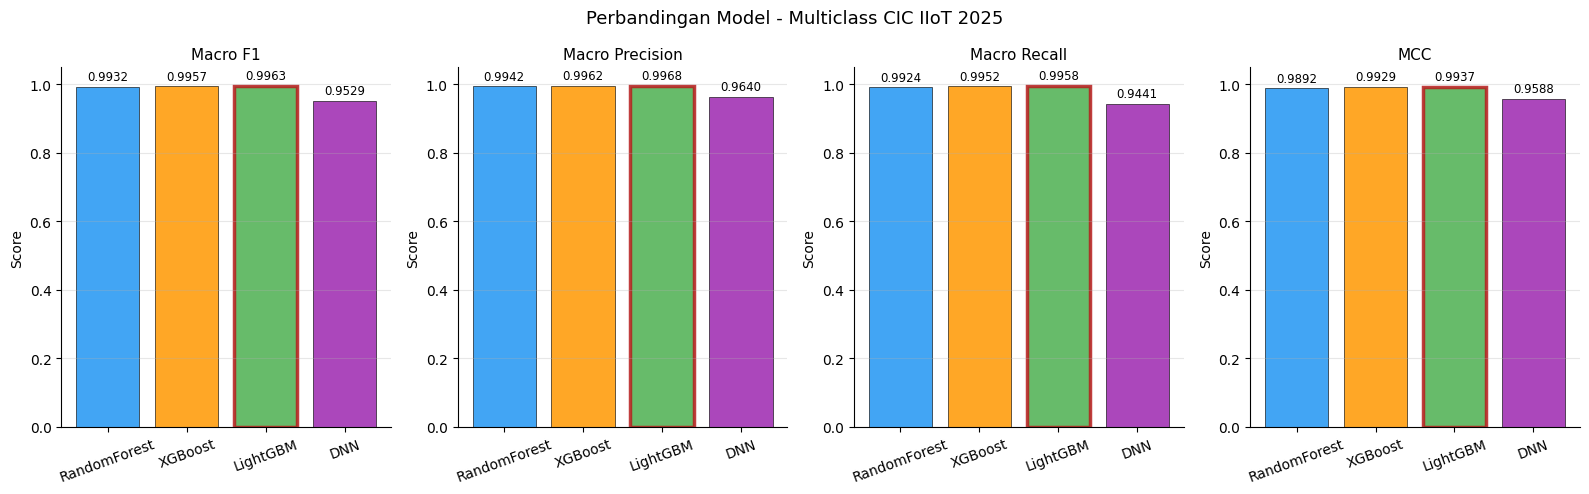

  Figure 1 tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Results/Visualizations/Langkah9_Multiclass_Perbandingan_Model.png


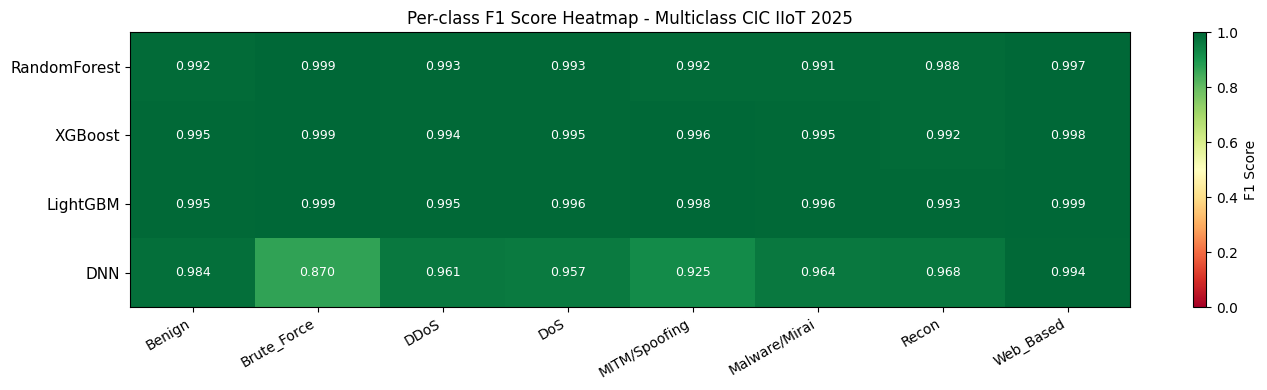

  Figure 2 tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Results/Visualizations/Langkah9_Multiclass_F1_Heatmap.png


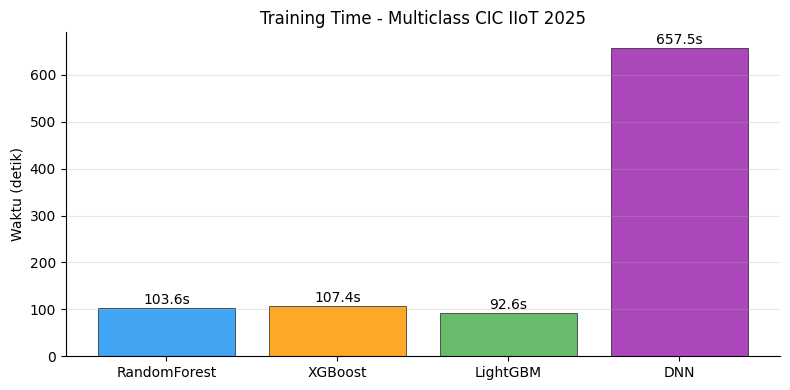

  Figure 3 tersimpan: /content/drive/My Drive/Framework/CICIIoT2025/Results/Visualizations/Langkah9_Multiclass_Training_Time.png


In [ ]:
model_names  = list(all_results.keys())
colors_model = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0']

metrics_plot = {
    'Macro F1'       : [all_results[m]['macro_f1']      for m in model_names],
    'Macro Precision': [all_results[m]['macro_prec']     for m in model_names],
    'Macro Recall'   : [all_results[m]['macro_recall']   for m in model_names],
    'MCC'            : [all_results[m]['mcc']            for m in model_names],
}

# Figure 1: Bar chart perbandingan metrik utama
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Perbandingan Model - Multiclass CIC IIoT 2025',
             fontsize=13)
for ax, (metric_name, values) in zip(axes, metrics_plot.items()):
    bars = ax.bar(model_names, values, color=colors_model,
                  edgecolor='black', linewidth=0.5, alpha=0.85)
    ax.set_title(metric_name, fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8.5)
    best_idx = int(np.argmax(values))
    bars[best_idx].set_edgecolor('#B71C1C')
    bars[best_idx].set_linewidth(2.5)
plt.tight_layout()
comp_path = VISUALIZATION_DIR_IIOT + 'Langkah9_Multiclass_Perbandingan_Model.png'
plt.savefig(comp_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Figure 1 tersimpan: {comp_path}")

# Figure 2: Per-class F1 heatmap
f1_matrix = np.zeros((len(model_names), N_CLASSES))
for i, m in enumerate(model_names):
    for j, name in enumerate(label_list):
        f1_matrix[i, j] = all_results[m]['per_class'][name]['f1-score']

fig2, ax2 = plt.subplots(figsize=(14, 4))
im2 = ax2.imshow(f1_matrix, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax2.set_xticks(range(N_CLASSES))
ax2.set_yticks(range(len(model_names)))
ax2.set_xticklabels(label_list, rotation=30, ha='right', fontsize=10)
ax2.set_yticklabels(model_names, fontsize=11)
ax2.set_title('Per-class F1 Score Heatmap - Multiclass CIC IIoT 2025',
              fontsize=12)
plt.colorbar(im2, ax=ax2, label='F1 Score')
for i in range(len(model_names)):
    for j in range(N_CLASSES):
        val = f1_matrix[i, j]
        ax2.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=9,
                 color='black' if 0.3 < val < 0.85 else 'white')
plt.tight_layout()
f1_heatmap_path = VISUALIZATION_DIR_IIOT + 'Langkah9_Multiclass_F1_Heatmap.png'
plt.savefig(f1_heatmap_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Figure 2 tersimpan: {f1_heatmap_path}")

# Figure 3: Training time
fig3, ax3 = plt.subplots(figsize=(8, 4))
train_times = [all_train_time[m] for m in model_names]
bars3 = ax3.bar(model_names, train_times, color=colors_model,
                edgecolor='black', linewidth=0.5, alpha=0.85)
ax3.set_title('Training Time - Multiclass CIC IIoT 2025',
              fontsize=12)
ax3.set_ylabel('Waktu (detik)')
ax3.grid(axis='y', alpha=0.3)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
for bar, val in zip(bars3, train_times):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{val:.1f}s', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
time_path = VISUALIZATION_DIR_IIOT + 'Langkah9_Multiclass_Training_Time.png'
plt.savefig(time_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Figure 3 tersimpan: {time_path}")

####**9.9 Ringkasan Langkah 9**

In [ ]:
print(f"\n{'Model':<14} {'Macro F1':>10} {'Macro Prec':>11} "
      f"{'Macro Rec':>10} {'MCC':>8} {'Accuracy':>10} {'Train(s)':>10}")
print("-" * 75)
for m in model_names:
    res = all_results[m]
    print(f"  {m:<12} {res['macro_f1']:>10.4f} {res['macro_prec']:>11.4f} "
          f"{res['macro_recall']:>10.4f} {res['mcc']:>8.4f} "
          f"{res['accuracy']:>10.4f} {all_train_time[m]:>10.1f}")
print("-" * 75)

best_f1_model  = max(all_results, key=lambda m: all_results[m]['macro_f1'])
best_mcc_model = max(all_results, key=lambda m: all_results[m]['mcc'])
print(f"\nModel terbaik (Macro F1) : {best_f1_model} "
      f"({all_results[best_f1_model]['macro_f1']:.4f})")
print(f"Model terbaik (MCC)      : {best_mcc_model} "
      f"({all_results[best_mcc_model]['mcc']:.4f})")

print(f"\nFile tersimpan:")
print(f"  {FRAMEWORK_MODELS_DIR_IIOT}")
for fname in ['RF_multiclass.pkl', 'XGBoost_multiclass.json',
              'LightGBM_multiclass.pkl', 'DNN_multiclass.keras']:
    fpath = os.path.join(FRAMEWORK_MODELS_DIR_IIOT, fname)
    if os.path.exists(fpath):
        size = os.path.getsize(fpath) / 1024**2
        print(f"    {fname:<38} ({size:.2f} MB)")
print(f"  {FRAMEWORK_RESULTS_DIR_IIOT}")
print(f"    langkah9_multiclass_results.json")
print(f"    langkah9_multiclass_summary.csv")

mem = psutil.virtual_memory()
print(f"\nRAM tersisa: {mem.available / 1024**3:.2f} GB")
gc.collect()

print("\nLanjut ke Langkah 10: Evaluation & Comparison")


Model            Macro F1  Macro Prec  Macro Rec      MCC   Accuracy   Train(s)
---------------------------------------------------------------------------
  RandomForest     0.9932      0.9942     0.9924   0.9892     0.9915      103.6
  XGBoost          0.9957      0.9962     0.9952   0.9929     0.9944      107.4
  LightGBM         0.9963      0.9968     0.9958   0.9937     0.9951       92.6
  DNN              0.9529      0.9640     0.9441   0.9588     0.9677      657.5
---------------------------------------------------------------------------

Model terbaik (Macro F1) : LightGBM (0.9963)
Model terbaik (MCC)      : LightGBM (0.9937)

File tersimpan:
  /content/drive/My Drive/Framework/CICIIoT2025/Models/
    RF_multiclass.pkl                      (32.65 MB)
    XGBoost_multiclass.json                (6.24 MB)
    LightGBM_multiclass.pkl                (2.72 MB)
    DNN_multiclass.keras                   (0.32 MB)
  /content/drive/My Drive/Framework/CICIIoT2025/Results/
    langkah9_

## **Langkah 10: Evaluation & Comparison**

####**10.1 Setup dan Load Semua Hasil**

In [ ]:
os.makedirs(FRAMEWORK_RESULTS_DIR_IIOT, exist_ok=True)
os.makedirs(VISUALIZATION_DIR_IIOT,     exist_ok=True)

# Load hasil Langkah 9 jika all_results tidak ada di memory
if 'all_results' not in globals() or len(all_results) == 0:
    print("all_results tidak ditemukan di memory, loading dari disk...")
    results_json_path = os.path.join(FRAMEWORK_RESULTS_DIR_IIOT,
                                     'langkah9_multiclass_results.json')
    assert os.path.exists(results_json_path), \
        f"ERROR: {results_json_path} tidak ditemukan. Jalankan Langkah 9 terlebih dahulu."
    with open(results_json_path, 'r') as f:
        all_results_loaded = json.load(f)
    # Konversi ke format yang sama dengan all_results Langkah 9
    all_results = {}
    for model_name, res in all_results_loaded.items():
        all_results[model_name] = res
    print(f"  Results loaded untuk: {list(all_results.keys())}")
else:
    print(f"  all_results tersedia di memory: {list(all_results.keys())}")

model_names = ['RandomForest', 'XGBoost', 'LightGBM', 'DNN']
label_list  = [LABEL_NAMES_IIOT[i] for i in range(N_CLASSES)]

# Load baseline results jika ada
BASELINE_RESULTS_FILE = os.path.join(BASELINE_RESULTS_DIR_IIOT,
                                     'baseline_multiclass_results.json')
has_baseline = os.path.exists(BASELINE_RESULTS_FILE)

if has_baseline:
    with open(BASELINE_RESULTS_FILE, 'r') as f:
        baseline_results = json.load(f)
    print(f"\nBaseline results ditemukan: {list(baseline_results.keys())}")
else:
    print(f"\nBaseline results tidak ditemukan di:")
    print(f"  {BASELINE_RESULTS_FILE}")
    print(f"  Evaluasi akan fokus pada perbandingan antar model framework.")

print(f"\nModel yang akan dievaluasi : {model_names}")
print(f"Jumlah kelas               : {N_CLASSES}")
print(f"Jumlah sampel test         : {len(y_test):,}")

  all_results tersedia di memory: ['RandomForest', 'XGBoost', 'LightGBM', 'DNN']

Baseline results tidak ditemukan di:
  /content/drive/My Drive/CICIIoT2025/Baseline8Multiclass/Results/baseline_multiclass_results.json
  Evaluasi akan fokus pada perbandingan antar model framework.

Model yang akan dievaluasi : ['RandomForest', 'XGBoost', 'LightGBM', 'DNN']
Jumlah kelas               : 8
Jumlah sampel test         : 45,319


####**10.2 Tabel Ringkasan Metrik Utama - Framework**

In [ ]:
metrics_keys = [
    ('accuracy',     'Accuracy'),
    ('macro_prec',   'Macro Precision'),
    ('macro_recall', 'Macro Recall'),
    ('macro_f1',     'Macro F1'),
    ('mcc',          'MCC'),
    ('weighted_f1',  'Weighted F1'),
]

# Header tabel
header = f"  {'Metrik':<20}"
for m in model_names:
    header += f" {m:>14}"
print(header)
print("  " + "-" * (20 + 14 * len(model_names)))

for key, label in metrics_keys:
    row = f"  {label:<20}"
    for m in model_names:
        val = all_results[m].get(key, None)
        if val is not None:
            row += f" {val:>14.6f}"
        else:
            row += f" {'N/A':>14}"
    print(row)

print("  " + "-" * (20 + 14 * len(model_names)))

# Tandai nilai terbaik per metrik
print("\n  Nilai terbaik per metrik:")
for key, label in metrics_keys:
    vals = {m: all_results[m].get(key, 0) or 0 for m in model_names}
    best = max(vals, key=vals.get)
    print(f"    {label:<20} : {best} ({vals[best]:.6f})")

  Metrik                 RandomForest        XGBoost       LightGBM            DNN
  ----------------------------------------------------------------------------
  Accuracy                   0.991505       0.994439       0.995079       0.967696
  Macro Precision            0.994163       0.996157       0.996792       0.963999
  Macro Recall               0.992387       0.995207       0.995834       0.944139
  Macro F1                   0.993238       0.995669       0.996306       0.952897
  MCC                        0.989191       0.992915       0.993728       0.958847
  Weighted F1                0.991498       0.994435       0.995077       0.967587
  ----------------------------------------------------------------------------

  Nilai terbaik per metrik:
    Accuracy             : LightGBM (0.995079)
    Macro Precision      : LightGBM (0.996792)
    Macro Recall         : LightGBM (0.995834)
    Macro F1             : LightGBM (0.996306)
    MCC                  : LightGBM (0.99372

####**10.3 Tabel Per-Class Metrics - Semua Model**

In [ ]:
for model_name in model_names:
    print(f"\n  [{model_name}]")
    print(f"  {'Kelas':<20} {'Precision':>10} {'Recall':>10} "
          f"{'F1':>10} {'Support':>10}")
    print(f"  {'-'*57}")
    for name in label_list:
        pc      = all_results[model_name]['per_class'][name]
        support = int(pc['support'])
        print(f"  {name:<20} {pc['precision']:>10.4f} {pc['recall']:>10.4f} "
              f"{pc['f1-score']:>10.4f} {support:>10,}")
    print(f"  {'Macro avg':<20} "
          f"{all_results[model_name]['macro_prec']:>10.4f} "
          f"{all_results[model_name]['macro_recall']:>10.4f} "
          f"{all_results[model_name]['macro_f1']:>10.4f} "
          f"{len(y_test):>10,}")


  [RandomForest]
  Kelas                 Precision     Recall         F1    Support
  ---------------------------------------------------------
  Benign                   0.9833     0.9999     0.9915     15,734
  Brute_Force              0.9983     1.0000     0.9991        571
  DDoS                     0.9997     0.9864     0.9930      6,097
  DoS                      0.9920     0.9950     0.9935      6,362
  MITM/Spoofing            0.9853     0.9982     0.9917      2,750
  Malware/Mirai            0.9960     0.9870     0.9915      2,773
  Recon                    0.9988     0.9780     0.9883     10,096
  Web_Based                1.0000     0.9947     0.9973        936
  Macro avg                0.9942     0.9924     0.9932     45,319

  [XGBoost]
  Kelas                 Precision     Recall         F1    Support
  ---------------------------------------------------------
  Benign                   0.9907     0.9991     0.9949     15,734
  Brute_Force              0.9983     1.0000 

####**10.4 Analisis Kelas Sulit (Low F1)**

In [ ]:
print(f"  {'Kelas':<20} {'RF':>8} {'XGB':>8} {'LGB':>8} {'DNN':>8} {'Avg F1':>8}")
print(f"  {'-'*60}")

difficult_classes = []
for name in label_list:
    f1_vals = [all_results[m]['per_class'][name]['f1-score'] for m in model_names]
    avg_f1  = np.mean(f1_vals)
    row     = f"  {name:<20}"
    for v in f1_vals:
        row += f" {v:>8.4f}"
    row += f" {avg_f1:>8.4f}"
    print(row)
    if avg_f1 < 0.7:
        difficult_classes.append((name, avg_f1))

if difficult_classes:
    print(f"\n  Kelas dengan avg F1 < 0.7:")
    for name, avg in sorted(difficult_classes, key=lambda x: x[1]):
        print(f"    {name:<20} : avg F1 = {avg:.4f}")
else:
    print(f"\n  Semua kelas memiliki avg F1 >= 0.7.")

  Kelas                      RF      XGB      LGB      DNN   Avg F1
  ------------------------------------------------------------
  Benign                 0.9915   0.9949   0.9953   0.9842   0.9915
  Brute_Force            0.9991   0.9991   0.9991   0.8702   0.9669
  DDoS                   0.9930   0.9940   0.9949   0.9610   0.9857
  DoS                    0.9935   0.9951   0.9955   0.9571   0.9853
  MITM/Spoofing          0.9917   0.9962   0.9976   0.9249   0.9776
  Malware/Mirai          0.9915   0.9955   0.9960   0.9643   0.9868
  Recon                  0.9883   0.9921   0.9930   0.9679   0.9853
  Web_Based              0.9973   0.9984   0.9989   0.9936   0.9971

  Semua kelas memiliki avg F1 >= 0.7.


####**Simpan Laporan Evaluasi Final**

In [ ]:
# Tentukan model terbaik per metrik
best_per_metric = {
    label: max(model_names, key=lambda m: all_results[m].get(key, 0) or 0)
    for key, label in metrics_keys
}

eval_report = {
    'dataset'         : 'CIC IIoT 2025',
    'pendekatan'      : 'Multiclass (8 kelas sekaligus)',
    'n_test_samples'  : int(len(y_test)),
    'n_classes'       : N_CLASSES,
    'label_list'      : label_list,
    'model_results'   : {},
    'best_per_metric' : best_per_metric,
    'difficult_classes': [
        {'kelas': name, 'avg_f1': round(avg, 4)}
        for name, avg in difficult_classes
    ] if difficult_classes else [],
    'has_baseline_comparison': has_baseline,
}

for m in model_names:
    eval_report['model_results'][m] = {
        'accuracy'    : all_results[m]['accuracy'],
        'macro_prec'  : all_results[m]['macro_prec'],
        'macro_recall': all_results[m]['macro_recall'],
        'macro_f1'    : all_results[m]['macro_f1'],
        'weighted_f1' : all_results[m]['weighted_f1'],
        'mcc'         : all_results[m]['mcc'],
        'roc_auc_ovr' : all_results[m].get('roc_auc_ovr', None),
        'train_time_s': all_train_time.get(m, None),
        'per_class'   : {
            name: {
                'precision': round(all_results[m]['per_class'][name]['precision'], 4),
                'recall'   : round(all_results[m]['per_class'][name]['recall'],    4),
                'f1-score' : round(all_results[m]['per_class'][name]['f1-score'],  4),
                'support'  : int(all_results[m]['per_class'][name]['support']),
            }
            for name in label_list
        }
    }

report_path = os.path.join(FRAMEWORK_RESULTS_DIR_IIOT,
                           'langkah10_evaluation_report.json')
with open(report_path, 'w') as f:
    json.dump(eval_report, f, indent=4)
print(f"  Laporan JSON tersimpan : {report_path}")

# Simpan summary CSV lengkap (per-class + overall)
csv_rows = []
for m in model_names:
    # Row overall
    csv_rows.append({
        'Model'     : m,
        'Kelas'     : 'OVERALL',
        'Precision' : all_results[m]['macro_prec'],
        'Recall'    : all_results[m]['macro_recall'],
        'F1'        : all_results[m]['macro_f1'],
        'MCC'       : all_results[m]['mcc'],
        'Accuracy'  : all_results[m]['accuracy'],
        'Support'   : len(y_test),
    })
    # Row per kelas
    for name in label_list:
        pc = all_results[m]['per_class'][name]
        csv_rows.append({
            'Model'    : m,
            'Kelas'    : name,
            'Precision': round(pc['precision'], 4),
            'Recall'   : round(pc['recall'],    4),
            'F1'       : round(pc['f1-score'],  4),
            'MCC'      : '',
            'Accuracy' : '',
            'Support'  : int(pc['support']),
        })

df_full_csv = pd.DataFrame(csv_rows)
full_csv_path = os.path.join(FRAMEWORK_RESULTS_DIR_IIOT,
                             'langkah10_full_metrics.csv')
df_full_csv.to_csv(full_csv_path, index=False)
print(f"  Full metrics CSV tersimpan : {full_csv_path}")

  Laporan JSON tersimpan : /content/drive/My Drive/Framework/CICIIoT2025/Results/langkah10_evaluation_report.json
  Full metrics CSV tersimpan : /content/drive/My Drive/Framework/CICIIoT2025/Results/langkah10_full_metrics.csv
